# Notebook 02 — `counterfactual_oracle`

Create a small simulator-based reference landscape: the ground truth every later
notebook is measured against.

**Plan requirements**

- Use 500 states from the ~30% checkpoint.
- For every state, restore simulator state and execute actions 0, 1, 2.
- Compute `Q_CF(s,a) = r + γV(s')`; terminal `V = 0`.
- Compute `V_π(s) = Σ_a π(a|s) Q_CF(s,a)`, then `A_CF = Q_CF − V_π`.
- **CHECK:** `Σ_a π·A ≈ 0` per state; action values differ on a meaningful
  subset; restore/step logic is correct.

Logic lives in `oracle/` and `scripts/build_oracle.py`. Runtime: a few seconds
per seed for the oracle itself, plus ~5–10 s per seed for the Monte-Carlo
diagnostic.

---
## ▶ The one knob: which checkpoint the oracle is built on

**The plan says ~30%. This notebook defaults to 75%, and here is the evidence
for that.**

Notebook 01 measured `mean |A_CF|` — how far apart the three actions are — at
every checkpoint, using a 300-state mini-oracle:

| seed | 10% | 30% | 50% | 75% | 100% |
|------|-----|-----|-----|-----|------|
| 0 | 0.0039 | **0.0021** | 0.2396 | 0.3646 | 0.4416 |
| 1 | 0.0221 | **0.0419** | 0.3694 | 0.4416 | 0.4522 |
| 2 | 0.0053 | **0.0102** | 0.0108 | 0.1779 | 0.2547 |

At the 30% checkpoint the policy has not learned anything yet — 0/50 greedy
success on every seed, first goal reach at 39–55% of training. Its critic has
never seen a reward, so `V(s) ≈ −1/(1−γ) = −100` everywhere, `Q_CF(s,a)` is the
same for all three actions, and `A_CF ≈ 0`. Gate 2 ("A_CF is nontrivial") would
fail for a reason that has nothing to do with the method.

75% is the first checkpoint with a competent policy and a landscape with real
structure.

**Set `CHECKPOINT_FRACTION = 0.30` below to reproduce the plan literally.** The
notebook will run fine and report a degenerate landscape — that is a finding
about the checkpoint, not a bug. Section 8 runs every checkpoint side by side so
you can see the whole curve rather than trusting this one choice.

In [1]:
# ----------------------------------------------------------------------------
# EDIT ME
# ----------------------------------------------------------------------------
CHECKPOINT_FRACTION = 0.75      # 0.10 | 0.30 | 0.50 | 0.75 | 1.00
N_STATES            = 500       # the plan asks for 500
SAMPLING            = "window"  # "window" (policy-matched) | "all" | "stratified"
RUN_MC_CHECK        = True      # Monte-Carlo diagnostic, ~5-10 s per seed
FORCE_REBUILD       = False     # recompute even if the landscape file exists
# ----------------------------------------------------------------------------

## 0. Setup

In [2]:
import sys, pathlib, dataclasses
ROOT = pathlib.Path.cwd()
if not (ROOT / "config").is_dir():          # notebook launched from notebooks/
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import DEFAULT, ExperimentConfig, FIGURES_DIR, seed_dir
from dataio import load_landscape, validate_landscape, load_checkpoint, checkpoint_path
from oracle import gate2_report
from scripts.build_oracle import build_all, landscape_path
from utils.plotting import (
    plot_landscape_distributions, plot_state_space_landscape,
    plot_mc_comparison, savefig,
)

FIG = FIGURES_DIR / "nb02"
FIG.mkdir(parents=True, exist_ok=True)

ACTION_NAMES = ["0: push left", "1: no push", "2: push right"]   # MountainCar-v0

cfg = dataclasses.replace(
    DEFAULT,
    oracle=dataclasses.replace(
        DEFAULT.oracle,
        checkpoint_fraction=CHECKPOINT_FRACTION,
        n_states=N_STATES,
        sampling=SAMPLING,
        run_mc_check=RUN_MC_CHECK,
    ),
)
print("project root:", ROOT)
print(cfg.oracle)

project root: /home/claude/PPO_CF
OracleConfig(checkpoint_fraction=0.75, n_states=500, seed_for_states=0, sampling='window', state_window_frac=0.05, run_mc_check=True, mc_n_states=60, mc_rollouts=32, mc_horizon=200, spread_threshold=0.01, min_frac_states_with_spread=0.2)


## 1. Build the landscape

For each of the `N_STATES` evaluation states the engine restores the simulator,
executes all three actions once, and forms `Q_CF`, `V_π`, `A_CF`.

Before computing anything it runs two correctness checks, because an oracle
built on a broken restore would produce plausible-looking numbers that are
silently about the wrong transitions:

- **`validate_restore`** replays 300 transitions recorded during training —
  restore the stored `sim_state`, take the stored action, and compare the result
  against the `next_sim_state` and `reward` that actually occurred. This is
  ground truth, not a self-consistency check. It must match exactly.
- **`check_determinism`** confirms that restoring the same state and taking the
  same action twice gives identical results.

The build raises if the restore check fails, rather than continuing.

In [3]:
need = FORCE_REBUILD or not all(landscape_path(cfg, s).exists() for s in cfg.run.seeds)

if need:
    results = build_all(cfg)
else:
    print("landscape files already exist — loading from disk")
    print("set FORCE_REBUILD = True to recompute")
    results = None


=== seed 0 ==================================================
  checkpoint ckpt_075.pt  (fraction 75%, step 300,032)
  states     500 via 'window' from a pool of 40,016 rows within +/-20,000 steps
  restore    replayed 300 recorded transitions: state err 0.00e+00, reward err 0.00e+00, terminated agreement 1.000 -> PASS
  determinism PASS
  landscape  500 states x 3 actions in 0.0s


  MC check   60 states x 32 CRN rollouts: magnitude ratio 0.52, Pearson 0.41, best-action agreement 0.48 (7s)
  saved      nb01_baseline/seed_0/landscapes/oracle_ckpt075.npz  (79 KB)

=== seed 1 ==================================================
  checkpoint ckpt_075.pt  (fraction 75%, step 300,032)
  states     500 via 'window' from a pool of 40,016 rows within +/-20,000 steps


  restore    replayed 300 recorded transitions: state err 0.00e+00, reward err 0.00e+00, terminated agreement 1.000 -> PASS
  determinism PASS
  landscape  500 states x 3 actions in 0.0s


  MC check   60 states x 32 CRN rollouts: magnitude ratio 0.47, Pearson 0.42, best-action agreement 0.58 (6s)
  saved      nb01_baseline/seed_1/landscapes/oracle_ckpt075.npz  (78 KB)

=== seed 2 ==================================================
  checkpoint ckpt_075.pt  (fraction 75%, step 300,032)
  states     500 via 'window' from a pool of 40,016 rows within +/-20,000 steps
  restore    replayed 300 recorded transitions: state err 0.00e+00, reward err 0.00e+00, terminated agreement 1.000 -> PASS
  determinism PASS


  landscape  500 states x 3 actions in 0.0s


  MC check   60 states x 32 CRN rollouts: magnitude ratio 0.58, Pearson 0.57, best-action agreement 0.55 (10s)
  saved      nb01_baseline/seed_2/landscapes/oracle_ckpt075.npz  (79 KB)

all seeds done in 24.1s


In [4]:
lands = {s: load_landscape(landscape_path(cfg, s)) for s in cfg.run.seeds}
L = lands[cfg.run.seeds[0]]
pd.Series(L.meta).to_frame("value")

,value
seed,0
run_name,nb01_baseline
checkpoint_fraction,0.75
checkpoint_step,300032
gamma,0.99
env_id,MountainCar-v0
max_episode_steps,500
n_states,500
sampling,window
state_half_width_steps,20000


## 2. CHECK — the landscape is internally consistent

`validate_landscape` re-derives every stored quantity from its parts and checks
they agree:

- `a_cf == q_cf − v_pi`
- `v_pi == Σ_a π·q_cf`
- `q_cf == reward + γ·v_next·(1 − terminated)`
- `Σ_a π(a|s)·A_CF(s,a) == 0` — the policy-centering identity Gate 2 asks for
- π rows sum to 1, everything finite

In [5]:
clean = True
for s in cfg.run.seeds:
    print(f"seed {s}:")
    problems = validate_landscape(lands[s], gamma=cfg.ppo.gamma)
    print("  ->", problems if problems else "NO PROBLEMS")
    clean &= not problems
    print()
print("LANDSCAPE VALIDATION:", "PASS" if clean else "FAIL")

seed 0:
  states            500   actions 3
  max |sum pi*A_CF| 1.30e-05
  mean |A_CF|       0.5816
  median Q spread   0.6030
  problems          0
  -> NO PROBLEMS

seed 1:
  states            500   actions 3
  max |sum pi*A_CF| 1.25e-05
  mean |A_CF|       0.5794
  median Q spread   0.7406
  problems          0
  -> NO PROBLEMS

seed 2:
  states            500   actions 3
  max |sum pi*A_CF| 1.40e-05
  mean |A_CF|       0.3225
  median Q spread   0.0662
  problems          0
  -> NO PROBLEMS

LANDSCAPE VALIDATION: PASS


## 3. Gate 2 report

In [6]:
reports = {s: gate2_report(lands[s].data,
                           spread_threshold=cfg.oracle.spread_threshold,
                           frac_threshold=cfg.oracle.min_frac_states_with_spread)
           for s in cfg.run.seeds}

rep = pd.DataFrame({s: {k: v for k, v in r.items() if not isinstance(v, (dict, list))}
                    for s, r in reports.items()}).T
rep.index.name = "seed"
rep

,n_states,centering_max_abs,centering_mean_abs,finite,mean_abs_a_cf,median_spread,mean_spread,frac_states_spread_above_thr,n_terminal_transitions,critic_vs_vpi_mean_abs
seed,,,,,,,,,,
0,500,0.000013,0.000003,True,0.581563,0.60298,1.169547,0.984,9,0.586684
1,500,0.000012,0.000003,True,0.579404,0.740646,1.175355,0.958,21,0.720436
2,500,0.000014,0.000004,True,0.322454,0.066246,0.650952,0.928,9,0.509007


In [7]:
# Which action the landscape prefers, per seed. A degenerate landscape shows up
# here as one action taking ~100% of states, or as an even 1/3 split of noise.
pd.DataFrame({s: r["best_action_distribution"] for s, r in reports.items()},
             index=ACTION_NAMES).T.rename_axis("seed")

,0: push left,1: no push,2: push right
seed,,,
0,0.460,0.0,0.540
1,0.482,0.0,0.518
2,0.412,0.0,0.588


## 4. Advantage distributions and per-state spread

Plan output #2. What to look for:

- The three per-action histograms should be **distinguishable** — different
  means or different shapes. Three identical curves stacked on zero means the
  landscape carries no information.
- The spread histogram should have mass away from zero. `Q spread` is
  `max_a Q − min_a Q`; since every non-terminal MountainCar reward is −1, the
  spread is entirely `γ·(V(s'_max) − V(s'_min))`, i.e. it measures how much the
  critic distinguishes the three successor states.
- The argmax bar chart should not be a single bar at 100%.

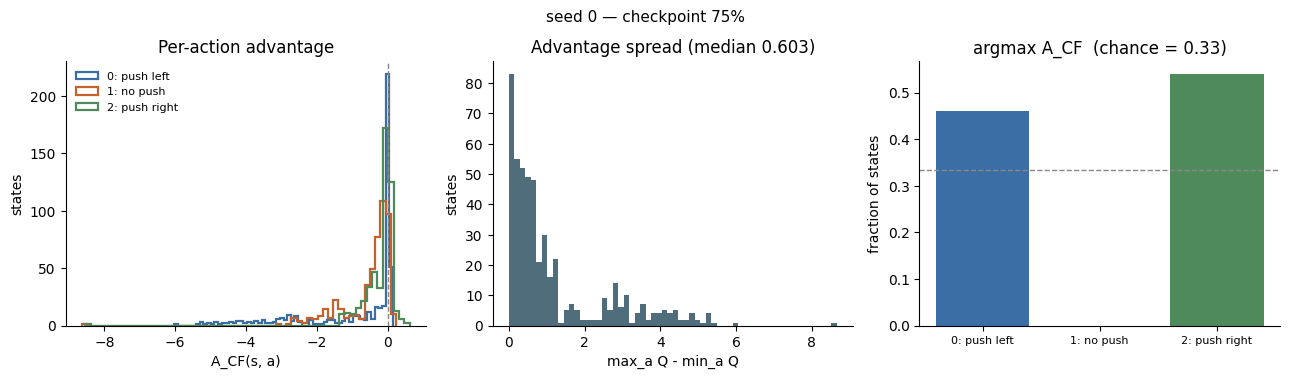

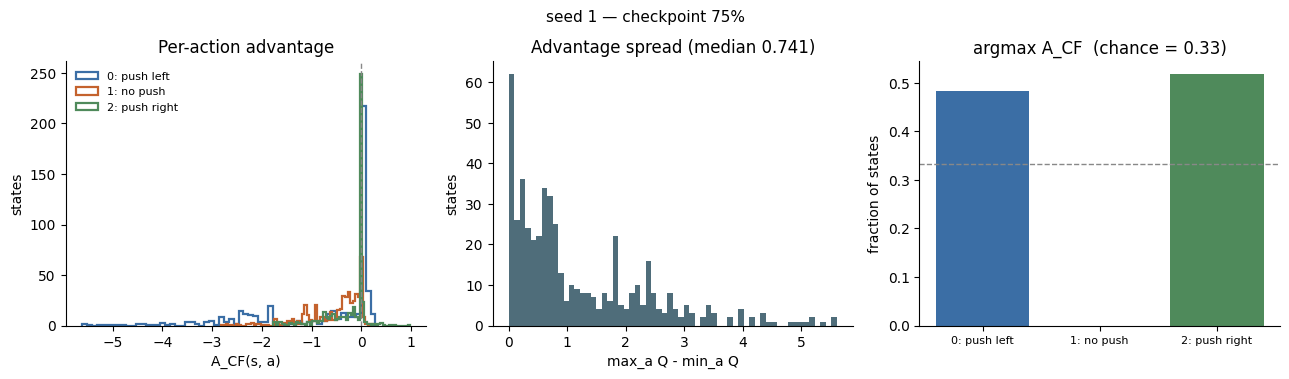

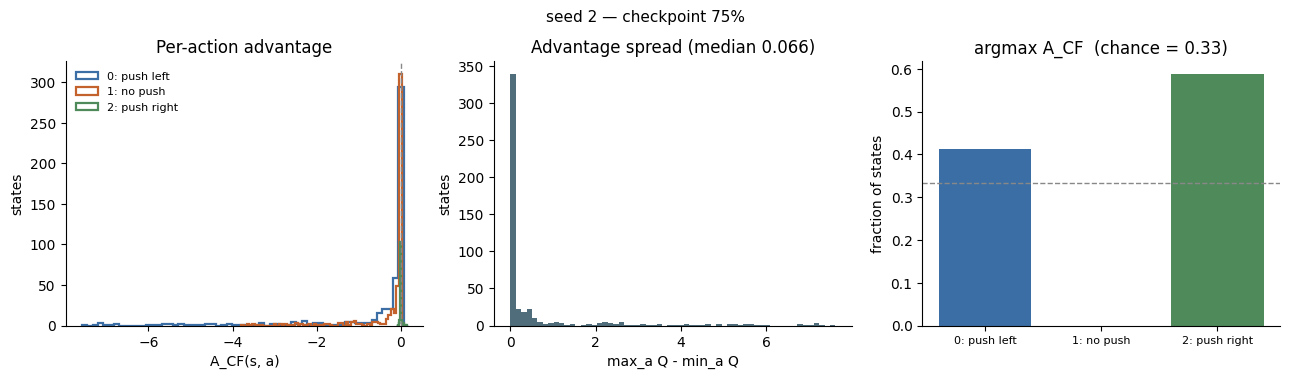

In [8]:
for s in cfg.run.seeds:
    fig = plot_landscape_distributions(lands[s], action_names=ACTION_NAMES)
    fig.suptitle(f"seed {s} — checkpoint {cfg.oracle.checkpoint_fraction:.0%}",
                 y=1.04, fontsize=11)
    savefig(fig, FIG / f"distributions_seed{s}_ckpt{int(CHECKPOINT_FRACTION*100):03d}.png")
    plt.show()

## 5. The landscape over the state space

MountainCar's state is 2-D, so the whole landscape can be drawn directly. This is
the sanity check that the signal is *structured* rather than noise: the best
counterfactual action should form coherent regions (roughly, push in the
direction of travel), not salt-and-pepper.

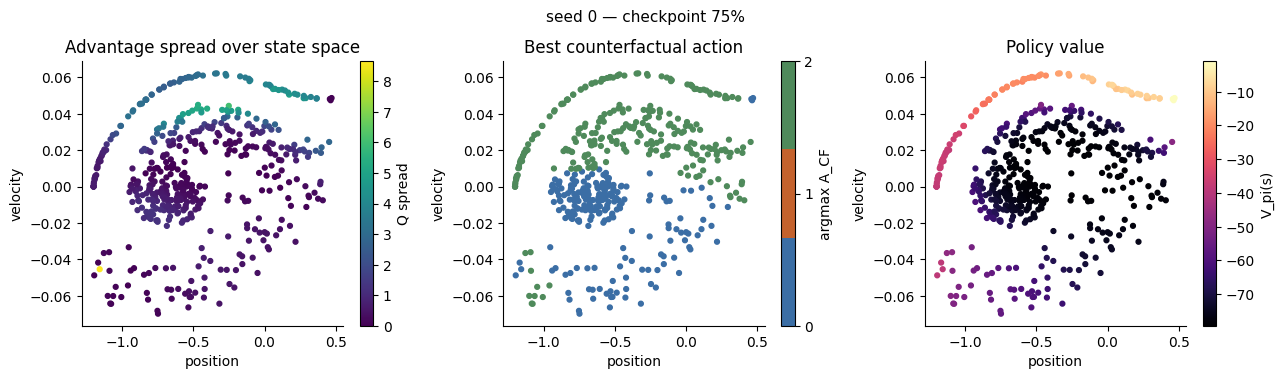

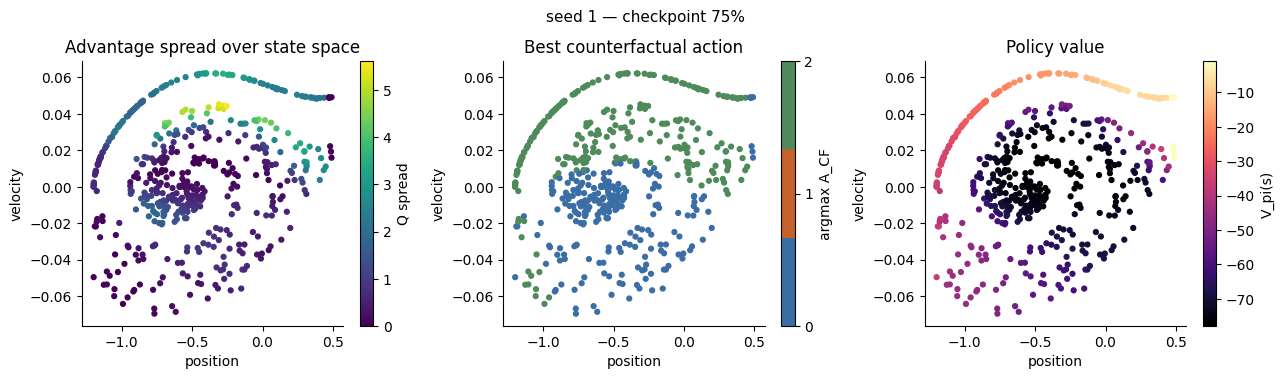

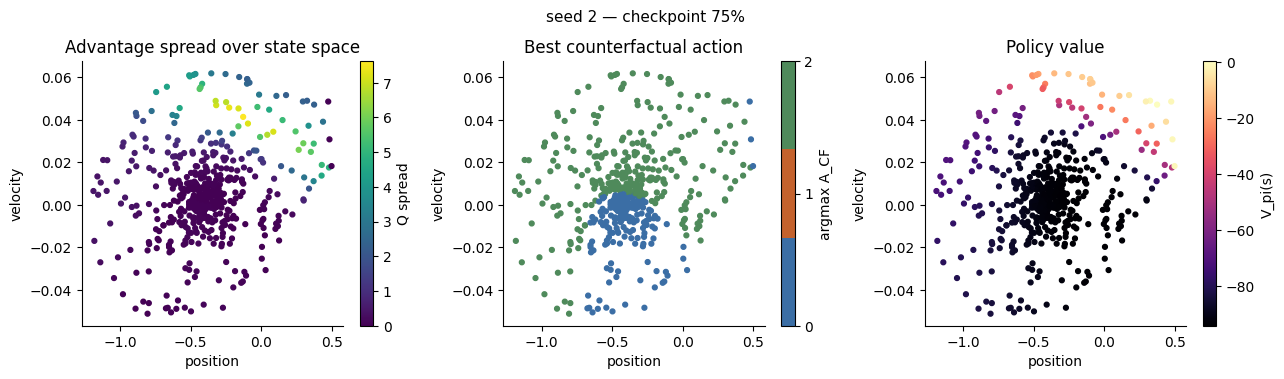

In [9]:
for s in cfg.run.seeds:
    fig = plot_state_space_landscape(lands[s])
    fig.suptitle(f"seed {s} — checkpoint {cfg.oracle.checkpoint_fraction:.0%}",
                 y=1.04, fontsize=11)
    savefig(fig, FIG / f"statespace_seed{s}_ckpt{int(CHECKPOINT_FRACTION*100):03d}.png")
    plt.show()

## 6. Individual states

The plan asks for several individual-state comparisons. Below: the states with
the largest advantage spread, and a random sample, showing π, Q_CF and A_CF
side by side.

In [10]:
def state_table(land, idx, title):
    d = land.data
    rows = []
    for i in idx:
        row = {"position": d["raw_obs"][i, 0], "velocity": d["raw_obs"][i, 1],
               "V_pi": d["v_pi"][i], "V_critic": d["v_critic"][i]}
        for a in range(land.n_actions):
            row[f"pi[{a}]"]   = d["pi"][i, a]
            row[f"Q_CF[{a}]"] = d["q_cf"][i, a]
            row[f"A_CF[{a}]"] = d["a_cf"][i, a]
        rows.append(row)
    print(title)
    return pd.DataFrame(rows).round(4)

L0 = lands[cfg.run.seeds[0]]
top = np.argsort(-L0.spread())[:8]
state_table(L0, top, f"seed {cfg.run.seeds[0]} — 8 states with the LARGEST advantage spread")

seed 0 — 8 states with the LARGEST advantage spread


,position,velocity,V_pi,V_critic,pi[0],Q_CF[0],A_CF[0],pi[1],Q_CF[1],A_CF[1],pi[2],Q_CF[2],A_CF[2]
0,-1.1569,-0.0454,-38.833698,-48.132000,0.9968,-38.806099,0.0276,0.0032,-47.462898,-8.6292,0.0000,-47.376099,-8.5424
1,-0.2508,0.0443,-55.878502,-53.583302,0.0000,-61.907501,-6.0290,0.0037,-58.967800,-3.0893,0.9962,-55.866798,0.0117
2,-0.4668,0.0449,-50.539398,-50.530102,0.0000,-55.894299,-5.3549,0.0035,-53.199799,-2.6604,0.9965,-50.529999,0.0094
3,-0.4030,0.0428,-58.288601,-57.591400,0.0000,-63.573299,-5.2847,0.0041,-60.988400,-2.6998,0.9959,-58.277302,0.0112
4,-0.4738,0.0429,-55.576500,-55.665600,0.0000,-60.848999,-5.2725,0.0040,-58.237701,-2.6612,0.9959,-55.565601,0.0109
5,-0.1847,0.0422,-61.785000,-59.068501,0.0000,-66.993896,-5.2089,0.0045,-64.537003,-2.7519,0.9955,-61.772400,0.0126
6,-0.4458,0.0424,-58.026798,-57.810799,0.0000,-63.215599,-5.1888,0.0042,-60.670799,-2.6441,0.9958,-58.015400,0.0113
7,-0.5070,0.0417,-57.220200,-57.658401,0.0000,-62.321201,-5.1009,0.0044,-59.810200,-2.5900,0.9956,-57.208599,0.0116


In [11]:
rng = np.random.default_rng(0)
state_table(L0, rng.choice(len(L0), 8, replace=False),
            f"seed {cfg.run.seeds[0]} — 8 random states")

seed 0 — 8 random states


,position,velocity,V_pi,V_critic,pi[0],Q_CF[0],A_CF[0],pi[1],Q_CF[1],A_CF[1],pi[2],Q_CF[2],A_CF[2]
0,-0.5376,0.0006,-78.765602,-78.587601,0.6808,-78.736397,0.0292,0.2381,-78.811401,-0.0458,0.0812,-78.876099,-0.1105
1,-0.5101,-0.0022,-78.602303,-78.483902,0.8003,-78.579201,0.0230,0.1671,-78.680199,-0.0780,0.0326,-78.768402,-0.1661
2,-0.8157,-0.0072,-70.010696,-69.609703,0.8905,-69.948196,0.0625,0.0995,-70.473999,-0.4633,0.0100,-70.969101,-0.9584
3,-0.4341,0.0207,-79.128098,-78.900101,0.0049,-79.204498,-0.0765,0.0597,-79.169403,-0.0413,0.9354,-79.125000,0.0030
4,-0.6086,-0.0078,-76.780602,-76.746201,0.9137,-76.755203,0.0254,0.0801,-77.031799,-0.2511,0.0062,-77.281601,-0.5010
5,-0.6108,-0.0148,-74.042801,-74.296501,0.9683,-74.027702,0.0151,0.0309,-74.491302,-0.4485,0.0008,-74.932198,-0.8894
6,0.0733,0.0537,-9.530400,-8.719800,0.0000,-13.994600,-4.4642,0.0022,-11.645100,-2.1148,0.9978,-9.525700,0.0047
7,-0.8916,-0.0130,-61.095200,-60.990700,0.9514,-61.068001,0.0273,0.0466,-61.607399,-0.5122,0.0019,-62.154598,-1.0594


## 7. Diagnostic — how much of `A_CF` is critic error?

The plan's oracle is the **one-step** form `Q_CF = r + γV(s')`. Note what that
means: if `V` were the true `V^π`, then `A_CF` would be *exactly* `A^π` — the
one-step form is not an approximation of the advantage, it is its definition.
Every bit of error in `A_CF` is therefore critic error, nothing else.

`mc_reference` measures how much of it there is: it takes action `a` from `s`,
follows π for up to `mc_horizon` steps, and averages over `mc_rollouts`
trajectories, leaning on the critic only at the tail.

**It uses common random numbers.** Rollout `m` from state `s` uses the same
random stream for every action, so `Q(s,a) − Q(s,a′)` is a *paired* difference.
This matters more than it sounds: the return itself varies by 5–10 across
rollouts while the advantage being measured is order 1, so with independent
randomness the noise swamps the signal and the diagnostic reports disagreement
that is entirely its own. With CRN the estimate is trustworthy: two independent
CRN seeds at 32 rollouts produce landscapes correlated at **Pearson 0.995**, and
the Pearson against `A_CF` is flat at ~0.40 from 8 rollouts to 128. Whatever
disagreement you see below is not sampling noise.

Read three separate questions, and do not collapse them into one number:

| question | metric | what "good" looks like |
|---|---|---|
| Is `A_CF` the right size? | ratio of mean magnitudes | near 1 |
| Does it point the right way? | Pearson / best-action agreement | high; chance agreement is 1/3 |
| Is the critic calibrated at all? | `V_critic` vs `V^π` | near the diagonal |

The magnitude ratio is deliberately a **ratio of mean |·|**, not a least-squares
slope through the origin. The slope is dominated by a handful of large-`|A_MC|`
states and reads ≈0.12 on this data against a true scale ratio near 0.5 — a good
example of a metric that looks rigorous and misleads by a factor of four.

A note on residual noise: `mean |A_MC|` still shrinks slightly with more rollouts
(1.10 at R=8, 1.05 at R=32, 0.93 at R=128) because leftover variance inflates a
magnitude. The magnitude ratio is therefore a mild **under**estimate at low R —
it moves 0.49 → 0.58 over that range. The Pearson does not move at all, so treat
correlation as the primary signal and the ratio as approximate.

,mean |A_CF|,mean |A_MC|,magnitude ratio,pearson,spearman,best-action agree,critic bias V-Vpi,mean MC s.e.
seed,,,,,,,,
0,0.5430,1.0526,0.5159,0.4059,0.0610,0.4833,-12.0803,0.2675
1,0.6083,1.3008,0.4676,0.4164,0.4079,0.5833,-14.0883,0.2320
2,0.2683,0.4611,0.5819,0.5748,0.4329,0.5500,-15.3100,0.3587



chance best-action agreement with K=3 is 0.33


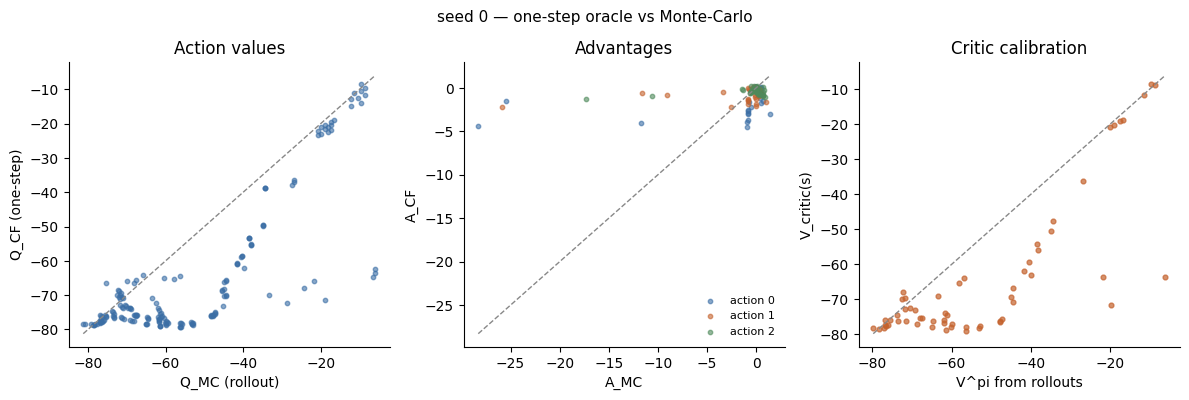

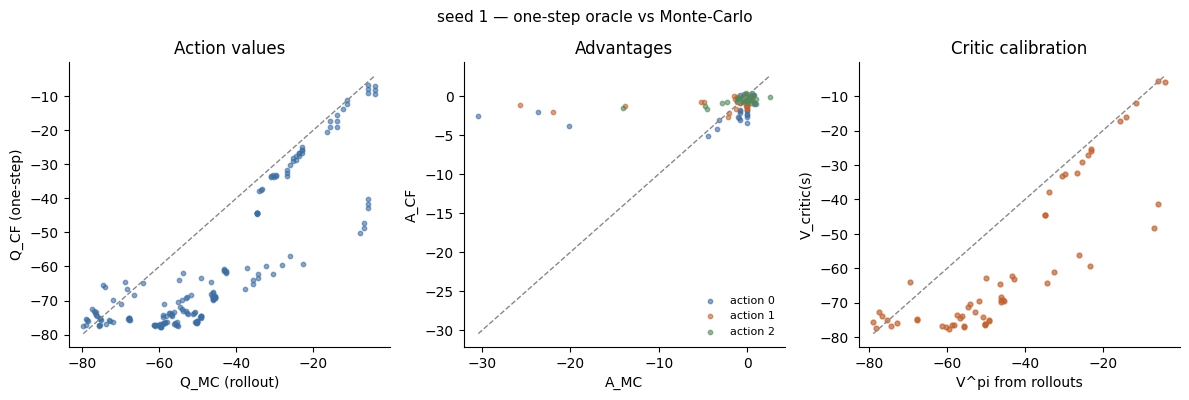

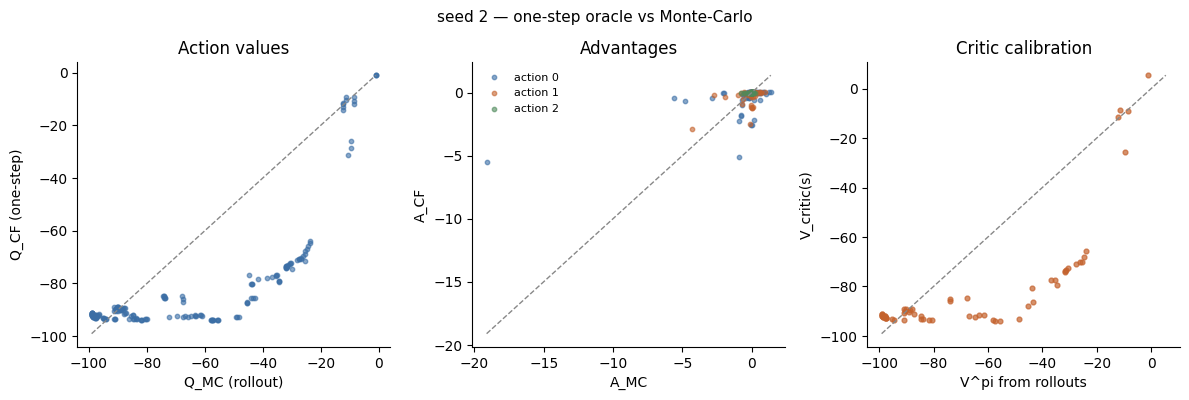

In [12]:
if "q_mc" in L0.data:
    from scipy.stats import pearsonr, spearmanr
    mcrows = []
    for s in cfg.run.seeds:
        d = lands[s].data
        m = len(d["q_mc"])
        a_cf, a_mc = d["a_cf"][:m], d["a_mc"]
        pi, q_mc = d["pi"][:m], d["q_mc"]
        mcrows.append({
            "seed": s,
            "mean |A_CF|": np.abs(a_cf).mean(),
            "mean |A_MC|": np.abs(a_mc).mean(),
            "magnitude ratio": np.abs(a_cf).mean() / max(np.abs(a_mc).mean(), 1e-9),
            "pearson": pearsonr(a_mc.ravel(), a_cf.ravel())[0],
            "spearman": spearmanr(a_mc.ravel(), a_cf.ravel())[0],
            "best-action agree": (a_mc.argmax(1) == a_cf.argmax(1)).mean(),
            "critic bias V-Vpi": (d["v_critic"][:m] - (pi * q_mc).sum(1)).mean(),
            "mean MC s.e.": d["q_mc_se"].mean() if "q_mc_se" in d else np.nan,
        })
    mcdf = pd.DataFrame(mcrows).set_index("seed").round(4)
    display(mcdf)
    print()
    print(f"chance best-action agreement with K={L0.n_actions} is {1/L0.n_actions:.2f}")

    for s in cfg.run.seeds:
        fig = plot_mc_comparison(lands[s])
        fig.suptitle(f"seed {s} — one-step oracle vs Monte-Carlo", y=1.04, fontsize=11)
        savefig(fig, FIG / f"mc_seed{s}_ckpt{int(CHECKPOINT_FRACTION*100):03d}.png")
        plt.show()
else:
    print("MC diagnostic not run (RUN_MC_CHECK = False)")

### Read this before writing Notebook 04

If `pearson` is low and `best-action agree` is near chance while the
`magnitude ratio` sits near 1, the situation is: **the one-step landscape has
roughly the right scale but is only weakly aligned with the true `A^π`, because
the critic's local shape is wrong even where its overall scale is reasonable.**

That is a fact about the critic, not about COCOA — but it lands squarely on
NB04, which is scored by "meaningful positive agreement with the explicit CF".
If the explicit reference is itself weakly correlated with the true advantage,
a *correct* COCOA could score badly against it, and a COCOA that happens to
mimic critic error could score well. Neither outcome means what Gate 4 intends.

Options, to settle before NB04 (recorded in `experiment_plan.md`):

- **(a)** Report NB04 against **both** references — the plan's one-step `A_CF`
  and the rollout `A_MC`. Cheapest, most informative, and does not change the
  plan's definition of the oracle. Recommended.
- **(b)** Improve the critic before building the oracle: extra value-only epochs
  on the frozen checkpoint until `V` matches rollout returns, then rebuild.
  Removes the confound at its source.
- **(c)** Accept the one-step oracle as-is and state explicitly that Gate 4 tests
  agreement-with-the-critic rather than agreement-with-`A^π`.

Do not dismiss the gap as Monte-Carlo noise without looking: the `mean MC s.e.`
column and the CRN convergence check above exist to rule that out.

## 8. Every checkpoint side by side

The choice at the top of this notebook is one point on a curve. This section
builds a small oracle at each of the five checkpoints so the choice is visible
rather than asserted. It is the evidence you would want before defending "we
used checkpoint X" to anyone.

Cheap: 150 states, no MC.

In [13]:
SWEEP = True   # set False to skip

if SWEEP:
    sweep_rows = []
    for frac in cfg.run.checkpoint_fractions:
        scfg = dataclasses.replace(
            cfg,
            oracle=dataclasses.replace(cfg.oracle, checkpoint_fraction=frac,
                                       n_states=150, run_mc_check=False),
        )
        try:
            res = build_all(scfg, verbose=False, tag="sweep")
        except Exception as exc:
            print(f"  {frac:.0%}: skipped ({exc})")
            continue
        for s, r in res.items():
            land = load_landscape(landscape_path(scfg, s, "sweep"))
            rep = gate2_report(land.data,
                               spread_threshold=cfg.oracle.spread_threshold,
                               frac_threshold=cfg.oracle.min_frac_states_with_spread)
            sweep_rows.append({
                "seed": s, "frac": f"{frac:.0%}",
                "mean |A_CF|": rep["mean_abs_a_cf"],
                "median spread": rep["median_spread"],
                "frac states w/ spread": rep["frac_states_spread_above_thr"],
                "max |sum pi*A|": rep["centering_max_abs"],
            })
    sweep = pd.DataFrame(sweep_rows)
    order = [f"{f:.0%}" for f in cfg.run.checkpoint_fractions]
    sweep["frac"] = pd.Categorical(sweep["frac"], categories=order, ordered=True)
    display(sweep.pivot(index="seed", columns="frac", values="mean |A_CF|").round(4))

frac,10%,30%,50%,75%,100%
seed,,,,,
0,0.0004,0.0000,0.2773,0.5638,0.5918
1,0.0007,0.0004,0.4758,0.6514,0.6235
2,0.0004,0.0001,0.0003,0.3127,0.5084


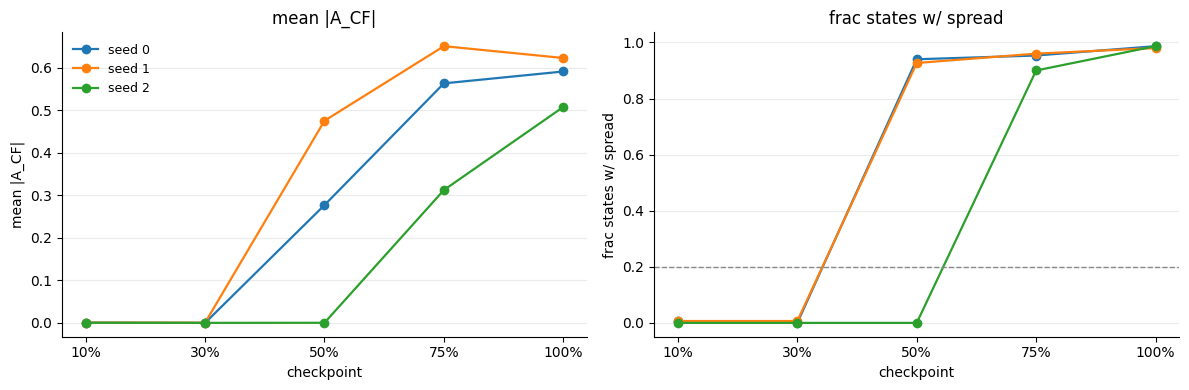

In [14]:
if SWEEP:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for i, (key, ax) in enumerate(zip(["mean |A_CF|", "frac states w/ spread"], axes)):
        piv = sweep.pivot(index="frac", columns="seed", values=key)
        for j, s in enumerate(piv.columns):
            ax.plot([f"{f:.0%}" for f in cfg.run.checkpoint_fractions],
                    piv[s].values, marker="o", lw=1.6, label=f"seed {s}")
        ax.set_xlabel("checkpoint"); ax.set_ylabel(key)
        ax.set_title(key); ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis="y", alpha=0.25)
        if i == 0:
            ax.legend(frameon=False, fontsize=9)
    axes[1].axhline(cfg.oracle.min_frac_states_with_spread, color="#888", ls="--", lw=1)
    fig.tight_layout()
    savefig(fig, FIG / "checkpoint_sweep.png")
    plt.show()

## 9. Gate 2 verdict

In [15]:
o = cfg.oracle
checks = {
    "restore/step reproduces recorded transitions exactly":
        (results is None) or all(r["restore"]["passed"] for r in results.values()),
    "simulator restore is deterministic":
        (results is None) or all(r["determinism"] for r in results.values()),
    "landscape files validate (a_cf, v_pi, q_cf all self-consistent)": clean,
    "policy-centered: max |sum_a pi*A_CF| < 1e-4":
        all(r["centering_max_abs"] < 1e-4 for r in reports.values()),
    "numerically finite": all(r["finite"] for r in reports.values()),
    f"nontrivial: >{o.min_frac_states_with_spread:.0%} of states have Q spread > {o.spread_threshold}":
        all(r["frac_states_spread_above_thr"] > o.min_frac_states_with_spread
            for r in reports.values()),
    "landscape does not collapse onto a single action":
        all(max(r["best_action_distribution"]) < 0.95 for r in reports.values()),
}

width = max(len(k) for k in checks)
for k, v in checks.items():
    print(f"  {'PASS' if v else 'FAIL'}  {k:<{width}}")

print()
print(f"GATE 2 @ checkpoint {o.checkpoint_fraction:.0%}:",
      "PASS — proceed to Notebook 03" if all(checks.values())
      else "FAIL — do not proceed; see section 8 before changing anything")

  PASS  restore/step reproduces recorded transitions exactly           
  PASS  simulator restore is deterministic                             
  PASS  landscape files validate (a_cf, v_pi, q_cf all self-consistent)
  PASS  policy-centered: max |sum_a pi*A_CF| < 1e-4                    
  PASS  numerically finite                                             
  PASS  nontrivial: >20% of states have Q spread > 0.01                
  PASS  landscape does not collapse onto a single action               

GATE 2 @ checkpoint 75%: PASS — proceed to Notebook 03


---

## What Notebook 03 inherits — and what it must not look at

Written to `runs/<run>/seed_<n>/landscapes/oracle_ckpt<NNN>.npz`.

NB03's whole claim is that COCOA recovers this landscape **from ordinary
trajectories alone**. So it may read only *which states* to produce a landscape
for, never the answer:

```python
from dataio import load_landscape
land = load_landscape(".../oracle_ckpt075.npz")

allowed = land.evaluation_states_only()   # index, sim_state, raw_obs, global_step
# FORBIDDEN in NB03: land.a_cf, land.q_cf, land.pi, land.v_pi, land.v_critic
```

`evaluation_states_only()` exists so that restriction is enforced by the code
rather than by memory.

### Two things to settle before writing NB03

1. **Policy matching.** `A_CF` is centered by π at *this* checkpoint
   (`meta["checkpoint_step"]`). If COCOA trains on all 400k rows it sees a
   mixture of every policy from training, and NB04 would then compare two
   objects defined against different policies. The evaluation states here were
   already drawn from a ±5% window around the checkpoint
   (`meta["state_half_width_steps"]`); use the same window for COCOA's training
   data via `Trajectories.window_around_step(center, half_width)`.

2. **What the magnitude of `A_CF` is worth.** Section 7 measures the gap between
   the one-step oracle and rollout estimates. If the magnitude ratio is far from
   1, then NB04's "magnitude ratio" metric is measuring the critic as much as it
   is measuring COCOA, and should be reported with that caveat rather than as a
   clean score. Direction (correlation, best-action agreement) is the more
   trustworthy signal.

### For NB04's null

With K = 3 and `Σ_a π·A_CF = 0`, the landscape has 2 degrees of freedom and
random best-action agreement is 1/3, not 1/2. Compute the null empirically by
shuffling state↔landscape pairs rather than assuming it.